# Vergleich: Schnittdynamik


In [8]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, spearmanr


In [12]:
DATA_DIR = Path('../../data')
INPUT_CSV = DATA_DIR / '04_analysis_results' / 'visual_features' / '03_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_cuts.csv'
print(f'Reading {INPUT_CSV}')
df = pd.read_csv(INPUT_CSV)
# Metriken aufbereiten
if {'cut_count', 'frames_scanned'}.issubset(df.columns):
    df['cuts_per_60_frames'] = (df['cut_count'] / df['frames_scanned'].replace(0, np.nan)) * 60.0
if {'cut_count', 'video_duration_seconds_est'}.issubset(df.columns):
    df['cuts_per_second'] = df['cut_count'] / df['video_duration_seconds_est'].replace(0, np.nan)
if {'cut_count', 'video_duration_seconds_est'}.issubset(df.columns):
    df['seconds_per_cut'] = df['video_duration_seconds_est'] / df['cut_count'].replace(0, np.nan)
elif {'cut_count', 'frames_scanned', 'video_fps'}.issubset(df.columns):
    duration_sec = df['frames_scanned'] / df['video_fps'].replace(0, np.nan)
    df['seconds_per_cut'] = duration_sec / df['cut_count'].replace(0, np.nan)
if 'seconds_per_cut' in df.columns:
    df['milliseconds_per_cut'] = df['seconds_per_cut'] * 1000.0
# Hauptmetrik: zeitbasiert, weil sie intuitiver zeigt, wie schnell ein Video geschnitten ist
if 'seconds_per_cut' in df.columns:
    metric = 'seconds_per_cut'
elif 'cuts_per_second' in df.columns:
    metric = 'cuts_per_second'
else:
    metric = 'cut_count'
metric_label = {
    'seconds_per_cut': 'Sekunden bis zum naechsten Schnitt',
    'cuts_per_second': 'Schnitte pro Sekunde',
    'cut_count': 'Anzahl Schnitte',
}.get(metric, metric)
print(f'Using metric: {metric} ({metric_label})')
preview_cols = ['influencer_type', 'cut_count']
for col in ['frames_scanned', 'video_fps', 'cuts_per_second', 'cuts_per_60_frames', 'seconds_per_cut', 'milliseconds_per_cut']:
    if col in df.columns:
        preview_cols.append(col)
print(df[preview_cols].groupby('influencer_type').agg(['count', 'mean', 'std']).round(3))


Reading ../../data/04_analysis_results/visual_features/03_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_cuts.csvUsing metric: seconds_per_cut (Sekunden bis zum nächsten Schnitt)                cut_count                 frames_scanned                      \                    count    mean     std          count      mean       std   influencer_type                                                                ai                    250   3.900  10.101            250   523.740   504.286   real                  250  14.952  31.970            250  1266.336  1469.292                   video_fps                cuts_per_second  ...         \                    count    mean    std           count  ...    std   influencer_type                                           ...          ai                    250  28.695  3.821             250  ...  0.485   real                  250  29.468  1.649             250  ...  0.979                   cuts_per_60_frames               seconds_per_cut         \   

In [13]:
summary_cols = ['cut_count']
for col in ['cuts_per_second', 'cuts_per_60_frames', 'seconds_per_cut', 'milliseconds_per_cut']:
    if col in df.columns:
        summary_cols.append(col)
summary = df.groupby('influencer_type')[summary_cols].describe().round(3)
display(summary)


cut_count                                              \
                    count    mean     std  min  25%  50%   75%    max   
influencer_type                                                         
ai                  250.0   3.900  10.101  0.0  0.0  0.0   1.0   57.0   
real                250.0  14.952  31.970  0.0  0.0  6.0  18.0  340.0   

                cuts_per_second         ... seconds_per_cut           \
                          count   mean  ...             75%      max   
influencer_type                         ...                            
ai                        250.0  0.182  ...           8.375  117.800   
real                      250.0  0.524  ...           5.995  132.117   

                milliseconds_per_cut                                          \
                               count      mean        std      min       25%   
influencer_type                                                                
ai                             100.0  8498.598  14685.840  181.667  1771.684   
real                           185.0  7988.030  17961.377  118.340  1233.974   

                                                 
                      50%       75%         max  
influencer_type                                  
ai               5059.028  8375.000  117800.000  
real             2237.500  5994.737  132116.667  

[2 rows x 40 columns]

/var/folders/xv/tws3wcdj24b6nwt9_f_365jr0000gn/T/ipykernel_36843/3325926309.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/xv/tws3wcdj24b6nwt9_f_365jr0000gn/T/ipykernel_36843/3325926309.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


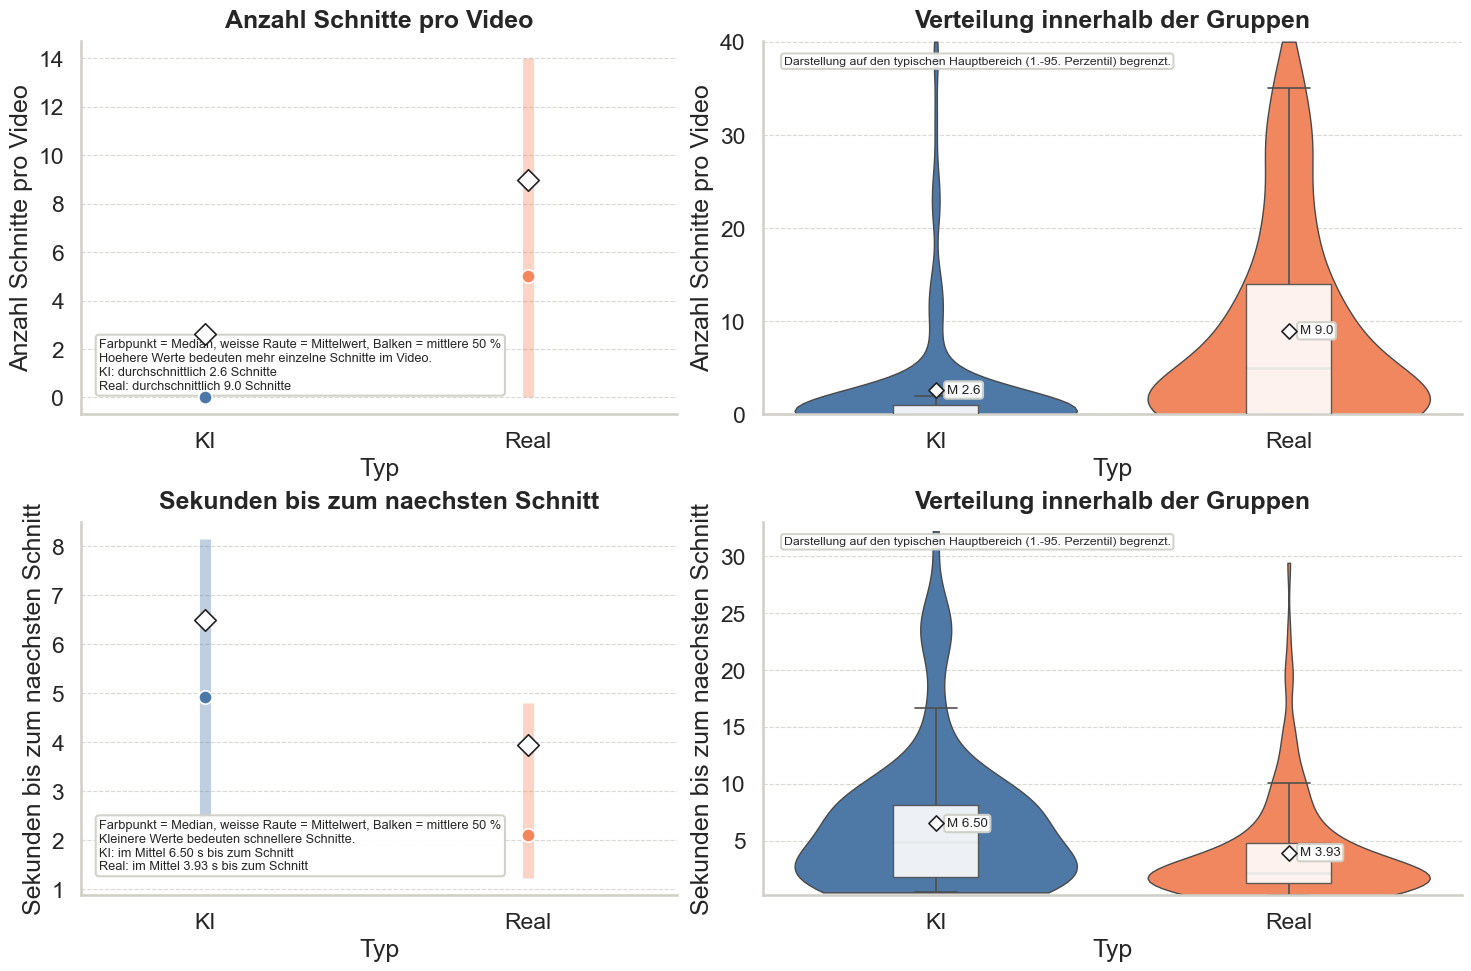

In [23]:
# Visualisierung der Schnittdynamik
sns.set_theme(
    style='whitegrid',
    context='talk',
    rc={
        'axes.facecolor': 'white',
        'figure.facecolor': 'white',
        'grid.color': '#d9d9d2',
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
        'axes.edgecolor': '#d0d0c8',
    },
)

ORDER = ['KI', 'Real']
PALETTE_COLOR = {'KI': '#4C78A8', 'Real': '#F5855B'}

df_plot = df.copy()
df_plot['typ'] = df_plot['influencer_type'].map({'ai': 'KI', 'real': 'Real'}).fillna(df_plot['influencer_type'])

plot_metrics = [
    ('cut_count', 'Anzahl Schnitte pro Video', 'Höhere Werte bedeuten mehr einzelne Schnitte im Video.'),
]
if 'seconds_per_cut' in df_plot.columns:
    plot_metrics.append(
        ('seconds_per_cut', 'Sekunden bis zum naechsten Schnitt', 'Kleinere Werte bedeuten schnellere Schnitte.')
    )

def fmt_value(metric_name, value):
    if pd.isna(value):
        return '-'
    return f'{value:.1f}' if metric_name == 'cut_count' else f'{value:.2f}'

fig, axes = plt.subplots(
    len(plot_metrics),
    2,
    figsize=(14.6, 4.8 * len(plot_metrics)),
    gridspec_kw={'width_ratios': [0.92, 1.08]},
    constrained_layout=True,
)
if len(plot_metrics) == 1:
    axes = np.array([axes])

for row_idx, (metric_col, metric_label, note_text) in enumerate(plot_metrics):
    ax_left, ax_right = axes[row_idx]
    vals_all = df_plot[metric_col].dropna()
    q_low, q_high = vals_all.quantile([0.01, 0.95])
    plot_df = df_plot[(df_plot[metric_col] >= q_low) & (df_plot[metric_col] <= q_high)].copy()

    summary = (
        plot_df.groupby('typ')[metric_col]
        .agg(
            n='count',
            mean='mean',
            median='median',
            q1=lambda s: s.quantile(0.25),
            q3=lambda s: s.quantile(0.75),
        )
        .reindex(ORDER)
    )

    x_positions = [0.00, 0.26]
    for x, grp in zip(x_positions, ORDER):
        row = summary.loc[grp]
        ax_left.vlines(x=x, ymin=row['q1'], ymax=row['q3'], color=PALETTE_COLOR[grp], linewidth=8, alpha=0.35)
        ax_left.scatter(x, row['median'], s=92, color=PALETTE_COLOR[grp], edgecolor='white', linewidth=1.2, zorder=4)
        ax_left.scatter(x, row['mean'], s=120, color='white', edgecolor='#222222', linewidth=1.2, marker='D', zorder=5)

    if metric_col == 'cut_count':
        info_text = (
            f"KI: durchschnittlich {fmt_value(metric_col, summary.loc['KI', 'mean'])} Schnitte\n"
            f"Real: durchschnittlich {fmt_value(metric_col, summary.loc['Real', 'mean'])} Schnitte"
        )
    else:
        info_text = (
            f"KI: im Mittel {fmt_value(metric_col, summary.loc['KI', 'mean'])} s bis zum Schnitt\n"
            f"Real: im Mittel {fmt_value(metric_col, summary.loc['Real', 'mean'])} s bis zum Schnitt"
        )

    ax_left.set_title(metric_label, pad=10, weight='semibold')
    ax_left.set_xlabel('Typ')
    ax_left.set_ylabel(metric_label)
    ax_left.set_xticks(x_positions)
    ax_left.set_xticklabels(ORDER)
    ax_left.set_xlim(-0.10, 0.38)
    ax_left.grid(axis='x', visible=False)
    ax_left.text(
        0.03,
        0.06,
        'Farbpunkt = Median, weisse Raute = Mittelwert, Balken = mittlere 50 %\n'
        + note_text + '\n'
        + info_text,
        transform=ax_left.transAxes,
        ha='left',
        va='bottom',
        fontsize=9.2,
        bbox=dict(boxstyle='round,pad=0.28', facecolor='white', edgecolor='#d0d0c8', alpha=0.96),
    )

    sns.violinplot(
        data=plot_df,
        x='typ',
        y=metric_col,
        order=ORDER,
        palette=PALETTE_COLOR,
        inner=None,
        cut=0,
        linewidth=1.0,
        saturation=0.95,
        ax=ax_right,
    )
    sns.boxplot(
        data=plot_df,
        x='typ',
        y=metric_col,
        order=ORDER,
        width=0.24,
        fliersize=0,
        boxprops={'facecolor': 'white', 'alpha': 0.90, 'edgecolor': '#4f4f4f', 'zorder': 3},
        whiskerprops={'linewidth': 1.2, 'color': '#4f4f4f'},
        capprops={'linewidth': 1.2, 'color': '#4f4f4f'},
        medianprops={'color': '#222222', 'linewidth': 1.8},
        ax=ax_right,
    )

    for x, grp in enumerate(ORDER):
        mean_val = summary.loc[grp, 'mean']
        ax_right.scatter(x, mean_val, s=60, color='white', edgecolor='#222222', linewidth=1.2, marker='D', zorder=5)
        ax_right.annotate(
            f"M {fmt_value(metric_col, mean_val)}",
            (x, mean_val),
            xytext=(8, 0),
            textcoords='offset points',
            va='center',
            fontsize=9.6,
            bbox=dict(boxstyle='round,pad=0.20', facecolor='white', edgecolor='#d0d0c8', alpha=0.96),
        )

    ax_right.set_title('Verteilung innerhalb der Gruppen', pad=10, weight='semibold')
    ax_right.set_xlabel('Typ')
    ax_right.set_ylabel(metric_label)
    ax_right.set_xticks(range(len(ORDER)))
    ax_right.set_xticklabels(ORDER)
    ax_right.set_ylim(q_low, q_high)
    ax_right.grid(axis='x', visible=False)
    ax_right.text(
        0.03,
        0.96,
        'Darstellung auf den typischen Hauptbereich (1.-95. Perzentil) begrenzt.',
        transform=ax_right.transAxes,
        ha='left',
        va='top',
        fontsize=8.8,
        bbox=dict(boxstyle='round,pad=0.22', facecolor='white', edgecolor='#d0d0c8', alpha=0.92),
    )

for ax in np.ravel(axes):
    sns.despine(ax=ax, top=True, right=True)

plt.show()


In [24]:
# Signifikanztests laut Tabelle:
# - cut_count (Count): Mann-Whitney-U
# - cuts_per_second (metrisch): Mann-Whitney-U
# - video_length (metrisch): Mann-Whitney-U

results = []

metric_specs = [
    ('cut_count', 'Anzahl Schnitte pro Video'),
    ('seconds_per_cut', 'Sekunden bis zum naechsten Schnitt'),
]

if 'video_duration_seconds' in df.columns:
    metric_specs.append(('video_duration_seconds', 'Videolaenge (video_duration_seconds)'))
elif 'video_duration_seconds_est' in df.columns:
    metric_specs.append(('video_duration_seconds_est', 'Videolaenge (video_duration_seconds_est)'))

for m, label in metric_specs:
    if m not in df.columns:
        continue
    ai_vals = df.loc[df['influencer_type'] == 'ai', m].dropna()
    real_vals = df.loc[df['influencer_type'] == 'real', m].dropna()

    if len(ai_vals) == 0 or len(real_vals) == 0:
        continue

    u_stat, u_p = mannwhitneyu(ai_vals, real_vals, alternative='two-sided')

    results.append({
        'metric': m,
        'label': label,
        'n_ai': len(ai_vals),
        'n_real': len(real_vals),
        'mean_ai': ai_vals.mean(),
        'mean_real': real_vals.mean(),
        'median_ai': ai_vals.median(),
        'median_real': real_vals.median(),
        'u_stat': u_stat,
        'u_p': u_p,
    })

results_df = pd.DataFrame(results).round(4)
display(results_df)


,metric,label,n_ai,n_real,mean_ai,mean_real,median_ai,median_real,u_stat,u_p
0,cut_count,Anzahl Schnitte pro Video,250,250,3.9000,14.9520,0.0000,6.0000,16918.5,0.0000
1,seconds_per_cut,Sekunden bis zum nächsten Schnitt,100,185,8.4986,7.9880,5.0590,2.2375,11309.5,0.0019
2,video_duration_seconds,Videolänge (video_duration_seconds),250,250,18.1252,42.7767,11.5635,24.6835,18188.0,0.0000


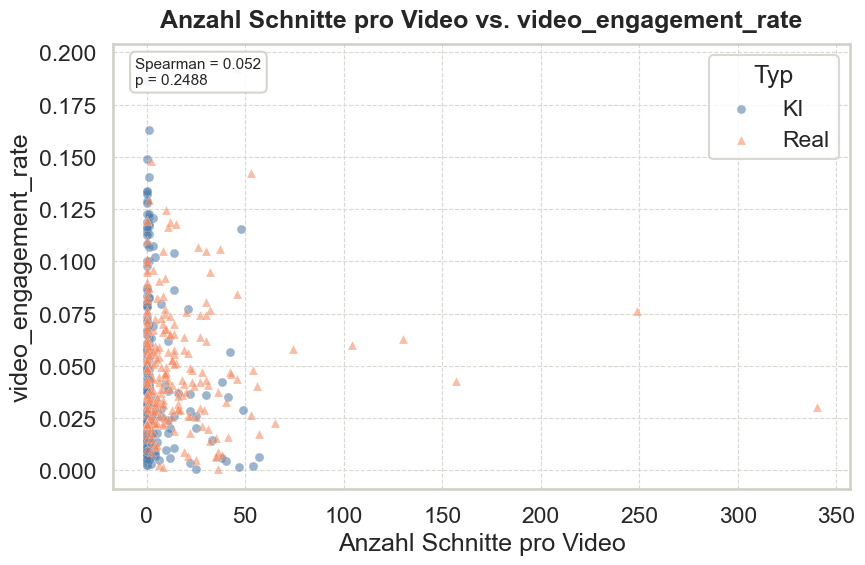

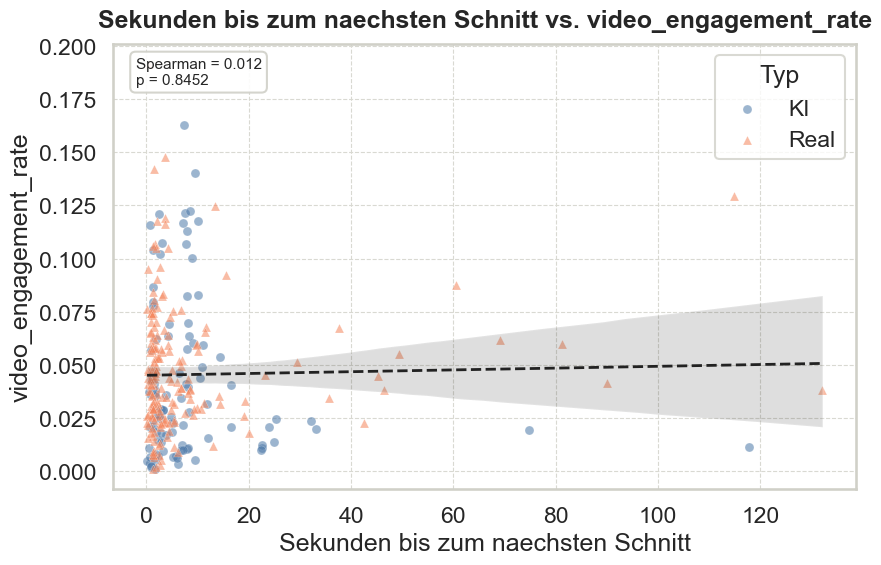

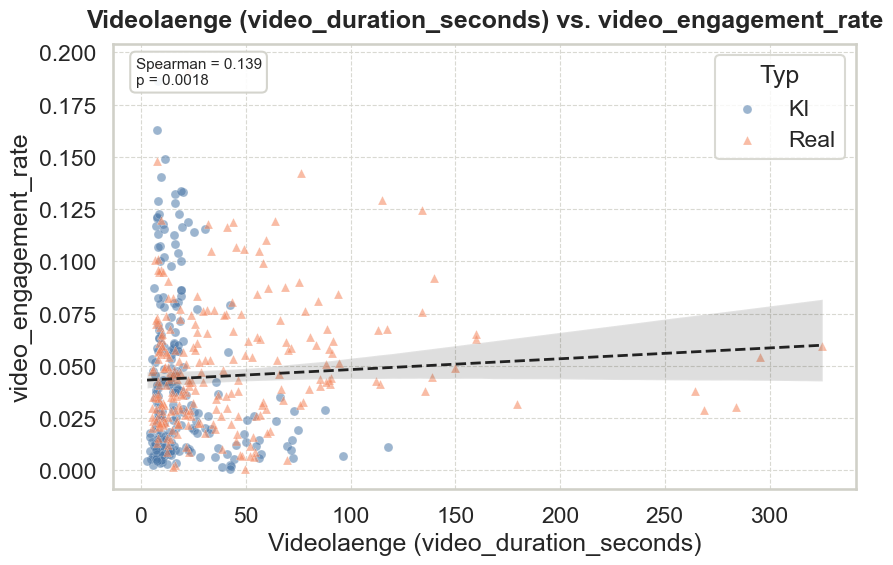

,metric,label,Korrelation_zu,method,Spearman_rho,p_Wert
0,cut_count,Anzahl Schnitte pro Video,video_engagement_rate,Spearman,0.0517,0.2488
1,seconds_per_cut,Sekunden bis zum nächsten Schnitt,video_engagement_rate,Spearman + Regression,0.0116,0.8452
2,video_duration_seconds,Videolänge (video_duration_seconds),video_engagement_rate,Spearman + Regression,0.1394,0.0018


In [26]:
# Korrelationsanalysen laut Tabelle:
# - cut_count: Spearman
# - cuts_per_second: Spearman + lineare Regression
# - video_length: Spearman + lineare Regression

sns.set_theme(
    style='whitegrid',
    context='talk',
    rc={
        'axes.facecolor': 'white',
        'figure.facecolor': 'white',
        'grid.color': '#d9d9d2',
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
        'axes.edgecolor': '#d0d0c8',
    },
)
sns.set_palette(['#4C78A8', '#F5855B'])

df_plot = df.copy()
df_plot['typ'] = df_plot['influencer_type'].map({'ai': 'KI', 'real': 'Real'}).fillna(df_plot['influencer_type'])
PALETTE_COLOR = {'KI': '#4C78A8', 'Real': '#F5855B'}
MARKER = {'KI': 'o', 'Real': '^'}

corr_results = []
engagement_col = 'likes' if 'likes' in df_plot.columns else ('video_engagement_rate' if 'video_engagement_rate' in df_plot.columns else None)

metric_specs = [
    ('cut_count', 'Anzahl Schnitte pro Video', False),
    ('seconds_per_cut', 'Sekunden bis zum naechsten Schnitt', True),
]
if 'video_duration_seconds' in df_plot.columns:
    metric_specs.append(('video_duration_seconds', 'Videolaenge (video_duration_seconds)', True))
elif 'video_duration_seconds_est' in df_plot.columns:
    metric_specs.append(('video_duration_seconds_est', 'Videolaenge (video_duration_seconds_est)', True))

if engagement_col is not None:
    for metric_col, metric_label, use_regression in metric_specs:
        if metric_col not in df_plot.columns:
            continue

        plot_df = df_plot[[metric_col, engagement_col, 'typ']].dropna().copy()
        if plot_df.empty:
            continue

        if engagement_col == 'likes':
            plot_df['engagement_plot'] = np.log10(plot_df[engagement_col] + 1.0)
            y_col = 'engagement_plot'
            y_label = 'log10(Likes + 1)'
        else:
            y_col = engagement_col
            y_label = engagement_col

        rho, pval = spearmanr(plot_df[metric_col], plot_df[engagement_col], nan_policy='omit')
        corr_results.append({
            'metric': metric_col,
            'label': metric_label,
            'Korrelation_zu': engagement_col,
            'method': 'Spearman + Regression' if use_regression else 'Spearman',
            'Spearman_rho': rho,
            'p_Wert': pval,
        })

        fig, ax = plt.subplots(figsize=(9, 6))
        for grp in ['KI', 'Real']:
            sub = plot_df[plot_df['typ'] == grp]
            sns.scatterplot(
                data=sub,
                x=metric_col,
                y=y_col,
                color=PALETTE_COLOR[grp],
                marker=MARKER[grp],
                edgecolor='white',
                linewidth=0.25,
                s=42,
                alpha=0.55,
                ax=ax,
                label=grp,
            )

        if use_regression:
            sns.regplot(
                data=plot_df,
                x=metric_col,
                y=y_col,
                scatter=False,
                ci=95,
                line_kws={'color': '#222222', 'linewidth': 2.0, 'linestyle': '--'},
                ax=ax,
            )

        ax.set_title(f'{metric_label} vs. {y_label}', pad=12, weight='semibold')
        ax.set_xlabel(metric_label)
        ax.set_ylabel(y_label)

        ax.text(
            0.03,
            0.97,
            f'Spearman = {rho:.3f}\np = {pval:.4f}',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontsize=11,
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#d0d0c8', alpha=0.9),
        )

        ax.legend(title='Typ', frameon=True, facecolor='white', edgecolor='#d0d0c8', loc='best')
        plt.tight_layout()
        plt.show()
else:
    print('Keine Engagement-Spalte gefunden. Korrelationsanalyse wurde uebersprungen.')

corr_df = pd.DataFrame(corr_results).round(4)
display(corr_df)


In [27]:
print('Kurzinterpretation:')

def sig_label(p):
    return 'signifikant' if pd.notna(p) and p < 0.05 else 'nicht signifikant'

if 'results_df' in globals() and not results_df.empty:
    for _, row in results_df.iterrows():
        mean_diff = row['mean_ai'] - row['mean_real']
        direction = 'hoeher bei KI' if mean_diff > 0 else ('hoeher bei Real' if mean_diff < 0 else 'kein Mittelwertunterschied')
        if row['metric'] == 'cut_count':
            print(f"- Schnittdynamik (cut_count): Mann-Whitney ist {sig_label(row['u_p'])} (p={row['u_p']:.4f}). Interpretation: Höherer Median/Mittelwert zeigt dynamischere Videobearbeitung ({direction}).")
        elif row['metric'] == 'seconds_per_cut':
            speed_direction = 'kuerzer bei KI' if mean_diff < 0 else ('kuerzer bei Real' if mean_diff > 0 else 'kein Unterschied')
            print(f"- Zeit bis zum naechsten Schnitt (seconds_per_cut): Mann-Whitney ist {sig_label(row['u_p'])} (p={row['u_p']:.4f}). Interpretation: Kleinere Werte bedeuten schnellere Schnitte ({speed_direction}).")
        elif row['metric'] in ['video_duration_seconds', 'video_duration_seconds_est']:
            print(f"- Videolaenge ({row['metric']}): Mann-Whitney ist {sig_label(row['u_p'])} (p={row['u_p']:.4f}). Interpretation: Unterschiede in der Laenge zwischen KI- und Real-Videos ({direction}).")
else:
    print('- Keine ausreichenden Daten für Gruppenvergleiche vorhanden.')

if 'corr_df' in globals() and not corr_df.empty:
    for _, row in corr_df.iterrows():
        rho = row['Spearman_rho']
        p = row['p_Wert']
        direction = 'positiv' if rho > 0 else ('negativ' if rho < 0 else 'neutral')
        m = row['metric']
        if m == 'cut_count':
            print(f"- Engagement ~ cut_count (Spearman): {sig_label(p)} (rho={rho:.3f}, p={p:.4f}). Interpretation: {direction}er Zusammenhang von Schnitthaeufigkeit und Engagement.")
        elif m == 'seconds_per_cut':
            print(f"- Engagement ~ seconds_per_cut (Spearman + Regression): {sig_label(p)} (rho={rho:.3f}, p={p:.4f}). Interpretation: Ein negativer Zusammenhang würde bedeuten, dass schnellere Schnitte tendenziell mit höherem Engagement einhergehen.")
        elif m in ['video_duration_seconds','video_duration_seconds_est']:
            print(f"- Engagement ~ Videolaenge (Spearman + Regression): {sig_label(p)} (rho={rho:.3f}, p={p:.4f}). Interpretation: Positiver Effekt bedeutet laengere Inhalte mit tendenziell mehr Interaktion.")


Kurzinterpretation:
- Schnittdynamik (cut_count): Mann-Whitney ist signifikant (p=0.0000). Interpretation: Höherer Median/Mittelwert zeigt dynamischere Videobearbeitung (höher bei Real).
- Zeit bis zum nächsten Schnitt (seconds_per_cut): Mann-Whitney ist signifikant (p=0.0019). Interpretation: Kleinere Werte bedeuten schnellere Schnitte (kürzer bei Real).
- Videolänge (video_duration_seconds): Mann-Whitney ist signifikant (p=0.0000). Interpretation: Unterschiede in der Länge zwischen KI- und Real-Videos (höher bei Real).
- Engagement ~ cut_count (Spearman): nicht signifikant (rho=0.052, p=0.2488). Interpretation: positiver Zusammenhang von Schnitthäufigkeit und Engagement.
- Engagement ~ seconds_per_cut (Spearman + Regression): nicht signifikant (rho=0.012, p=0.8452). Interpretation: Ein negativer Zusammenhang würde bedeuten, dass schnellere Schnitte tendenziell mit höherem Engagement einhergehen.
- Engagement ~ Videolänge (Spearman + Regression): signifikant (rho=0.139, p=0.0018). Int